In [18]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px

torch.manual_seed(12345)

class LinearToyModel(nn.Module):
  # Parameters from the paper: n = 20, m = 5, I_i = 0.7 ** i
  # Note: Some of these parameters differ for certain graphs

  def __init__(self, m, n, n_instances, n_batches = 1024, feature_probability = None, importance = None, device = 'mps'):
    super().__init__()

    # We do this rather than passing them as default parameters so we can use the "device" parameter for .to(device)
    if feature_probability is None:
      feature_probability = torch.ones((n))
    if importance is None:
      importance = torch.ones((n))

    device = 'cuda' if torch.cuda.is_available() else 'mps'
    self.feature_probability = feature_probability.to(device)
    self.importance = importance.to(device)
    self.device = device

    self.n_instances = n_instances
    self.n = n
    self.n_batches = n_batches
    self.W = nn.Parameter(torch.empty((n_instances, n, m), device=device))
    nn.init.xavier_normal_(self.W)
    self.b = nn.Parameter(torch.zeros((n_instances, n),device=self.device))


  def forward(self, x):
    # x = [batch_size, n_instances, n]
    # W = [n_instances, n, m]

    # x = [batch_size, n_instances, 1, n]
    x = x.unsqueeze(-2)
    # W_expanded = [1, n_instances, n , m]
    W_expanded = self.W.unsqueeze(0)

    # h = [batch_size, n_instances, 1, m]
    h = x @ W_expanded
    # h = [batch_size,n_instances,m]
    h = h.squeeze(-2)

    W_extended2 = self.W.unsqueeze(0).transpose(-2,-1)
    h_extended = h.unsqueeze(-2)
    # W_extended2 = [1, n_instances, m,n]
    # x2 = [batch, instances, n]
    x2 = h_extended @ W_extended2
    x2 = (x2.squeeze(-2)) + self.b
    return x2

  def generate_data(self):
    feat = torch.rand(self.n_batches, self.n_instances, self.n, device=self.W.device)

    # This is like an if statement.
    # We are making a tensor where each element has 30% chance of showing element from our feat tensor and 70% chance of showing 0

    batch = torch.where(
        torch.rand((self.n_batches, self.n_instances, self.n), device=self.W.device) <= self.feature_probability,
        feat,
        torch.zeros((self.n_batches, self.n_instances, self.n), device=self.W.device)
    )

    return batch

In [22]:

class ReLUToyModel(nn.Module):
  # Parameters from the paper: n = 20, m = 5, I_i = 0.7 ** i



  def __init__(self, m, n, n_instances, n_batches = 1024, feature_probability = None, importance = None, device = 'cuda'):
    super().__init__()

    # We do this rather than passing them as default parameters so we can use the "device" parameter for .to(device)
    if feature_probability is None:
      feature_probability = torch.ones((n))
    if importance is None:
      importance = torch.ones((n))

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    self.feature_probability = feature_probability.to(device)
    self.importance = importance.to(device)
    self.device = device

    self.m = m
    self.n_instances = n_instances
    self.n = n
    self.n_batches = n_batches
    self.W = nn.Parameter(torch.empty((n_instances, n, m), device=device))
    nn.init.xavier_normal_(self.W)
    self.b = nn.Parameter(torch.zeros((n_instances, n),device=self.device))


  def forward(self, x):
    x = x.unsqueeze(-2)
    W_expanded = self.W.unsqueeze(0)
    h = x @ W_expanded
    h = h.squeeze(-2)
    W_extended2 = self.W.unsqueeze(0).transpose(-2,-1)
    h_extended = h.unsqueeze(-2)
    x2 = h_extended @ W_extended2
    x2 = (x2.squeeze(-2)) + self.b
    nonlin = nn.ReLU()
    return nonlin(x2)


  def generate_data(self):
      feat = torch.rand(self.n_batches, self.n_instances, self.n, device=self.W.device)

      # This is like an if statement.
      # We are making a tensor where each element has 30% chance of showing element from our feat tensor and 70% chance of showing 0

      batch = torch.where(
          torch.rand((self.n_batches, self.n_instances, self.n), device=self.W.device) <= self.feature_probability,
          feat,
          torch.zeros((self.n_batches, self.n_instances, self.n), device=self.W.device)
      )

      return batch

In [ ]:
def train(model, lr = 1e-3):
  optim = torch.optim.AdamW([model.W, model.b], lr=lr)

  steps = 10000


  for step in range(steps):
    optim.zero_grad()
    batch = model.generate_data()
    out = model(batch)

    loss = (model.importance * (batch.abs() - out)**2).mean(dim=(0,2)).sum()
    loss.backward()
    optim.step()

    if step % 1000 == 0:
      print("loss: ",loss)


In [ ]:
# Code for this  mostly taken verbatim from Anthropic's implementation to create graphs that look the same


def intro_diagram(model):
  from matplotlib import colors  as mcolors
  from matplotlib import collections  as mc

  WA = model.W.detach()

  plt.rcParams["axes.prop_cycle"] = plt.cycler("color", plt.cm.viridis(model.importance[0].cpu().numpy()))
  plt.rcParams['figure.dpi'] = 200
  N = len(WA[:,0])
  sel = range(model.n_instances)


  figs, axs = plt.subplots(1, len(sel), figsize=(2*len(sel),2))
  for i, ax in zip(sel, axs):
      W = WA[i].cpu().detach().numpy()
      colors = [mcolors.to_rgba(c)
                for c in plt.rcParams['axes.prop_cycle'].by_key()['color']]
      ax.scatter(W[:,0], W[:,1], c=colors[0:len(W[:,0])])
      ax.set_aspect('equal')
      ax.add_collection(mc.LineCollection(np.stack((np.zeros_like(W),W), axis=1), colors=colors))
      z = 1.5
      ax.set_facecolor('#FCFBF8')
      ax.set_xlim((-z,z))
      ax.set_ylim((-z,z))
      ax.tick_params(left = True, right = False , labelleft = False ,
                      labelbottom = False, bottom = True)
      for spine in ['top', 'right']:
          ax.spines[spine].set_visible(False)
      for spine in ['bottom','left']:
          ax.spines[spine].set_position('center')
  plt.show()



loss:  tensor(0.7643, device='mps:0', grad_fn=<SumBackward0>)
loss:  tensor(0.2987, device='mps:0', grad_fn=<SumBackward0>)
loss:  tensor(0.2794, device='mps:0', grad_fn=<SumBackward0>)
loss:  tensor(0.2792, device='mps:0', grad_fn=<SumBackward0>)
loss:  tensor(0.2725, device='mps:0', grad_fn=<SumBackward0>)
loss:  tensor(0.2696, device='mps:0', grad_fn=<SumBackward0>)
loss:  tensor(0.2736, device='mps:0', grad_fn=<SumBackward0>)
loss:  tensor(0.2728, device='mps:0', grad_fn=<SumBackward0>)
loss:  tensor(0.2668, device='mps:0', grad_fn=<SumBackward0>)
loss:  tensor(0.2736, device='mps:0', grad_fn=<SumBackward0>)


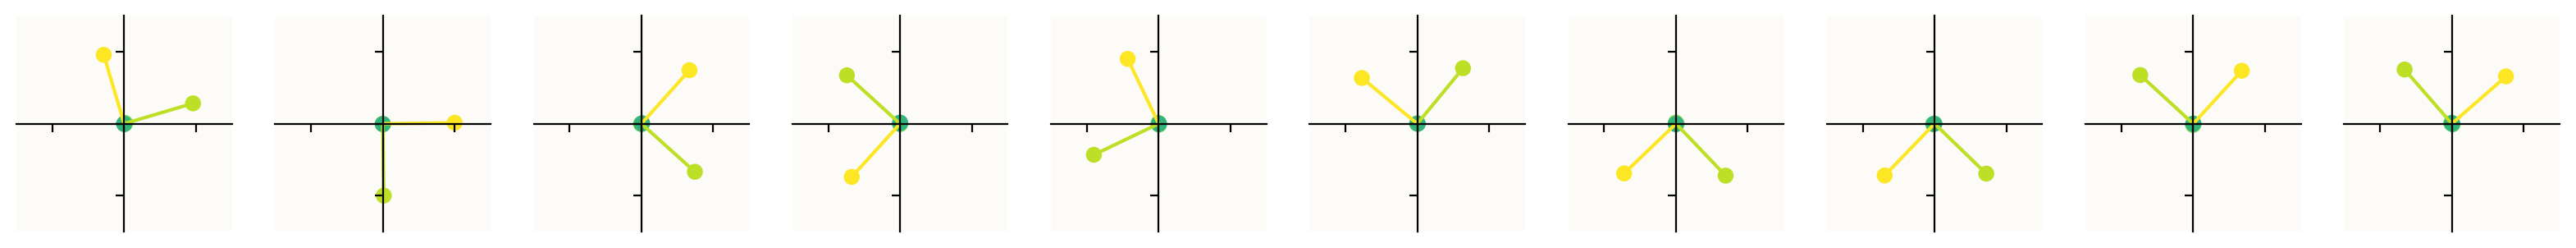

In [ ]:
model = LinearToyModel(m=2,n=5, n_instances=10, importance=(0.9**torch.arange(5))[None, :],  feature_probability = (20 ** -torch.linspace(0, 1, 10))[None,:, None])
train(model)
intro_diagram(model)

loss:  tensor(0.7144, grad_fn=<SumBackward0>)
loss:  tensor(0.2353, grad_fn=<SumBackward0>)
loss:  tensor(0.2206, grad_fn=<SumBackward0>)
loss:  tensor(0.2131, grad_fn=<SumBackward0>)
loss:  tensor(0.2072, grad_fn=<SumBackward0>)
loss:  tensor(0.2078, grad_fn=<SumBackward0>)
loss:  tensor(0.2057, grad_fn=<SumBackward0>)
loss:  tensor(0.2132, grad_fn=<SumBackward0>)
loss:  tensor(0.2052, grad_fn=<SumBackward0>)
loss:  tensor(0.2070, grad_fn=<SumBackward0>)


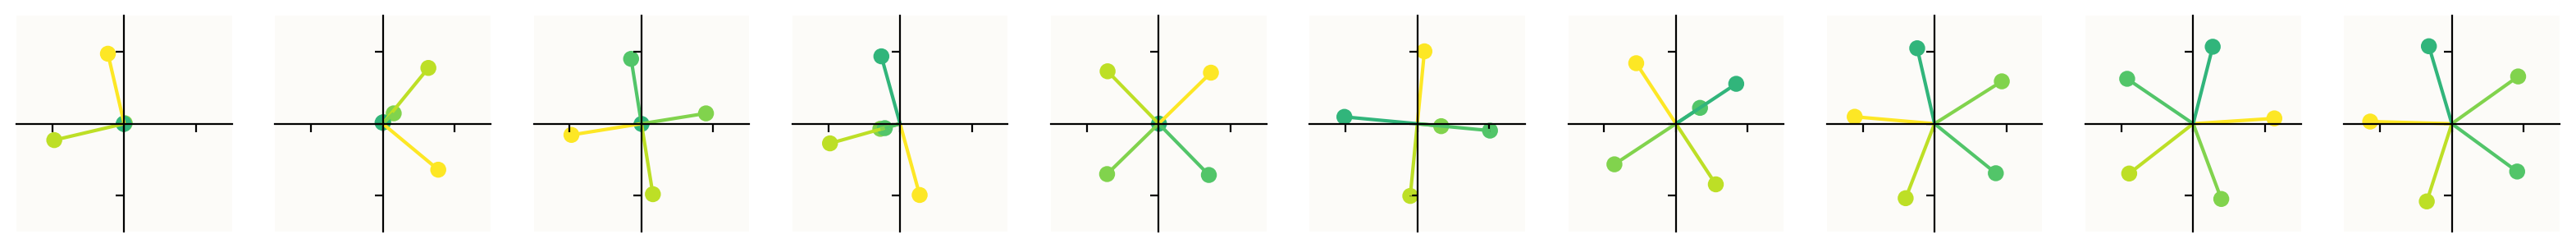

In [23]:
model = ReLUToyModel(n=5,m=2, n_instances = 10, importance=(0.9**torch.arange(5))[None, :],    feature_probability = (20 ** -torch.linspace(0, 1, 10))[None,:,None])
train(model)
intro_diagram(model)

In [24]:
from tqdm import tqdm

def render_features(model):
  W = model.W.detach()
  W_norm = W / (1e-5 + torch.linalg.norm(W,2,dim=-1,keepdim=True))


  interference = W_norm @ W.transpose(-1,-2)
  interference[:,torch.arange(model.n),torch.arange(model.n)] = 0 # This code sets the diagonal of our matrix to 0 because these will just be the interference of a feature with itself

  polysemanticity = torch.linalg.norm(interference,2, dim=-1).cpu()

  net_interference = (interference**2 * model.feature_probability[:, None, :]).sum(-1).cpu()
  norms = torch.linalg.norm(W,2,dim=-1).cpu()

  # W is shaped [n_instances, n, m]
  # W.transpose(-1,-2) is shaped like [n_instances, m, n]
  # WtW is shaped like [n_instances,n,n].
  # A bit unintuitive to variable name but done to avoid using einsum
  WtW = (W @ W.transpose(-1,-2)).cpu()
  x = torch.arange(model.n)

  which=np.s_[:]
  which_instances = np.arange(model.n_instances)[which]
  # Again, a lot of this code it taken verbatim from Anthropic's implementation so I can get similar graphs
  fig = make_subplots(rows=len(which_instances),
                      cols=2,
                      shared_xaxes=True,
                      vertical_spacing=0.02,
                      horizontal_spacing=0.1)


  for (row, inst) in tqdm(enumerate(which_instances), total=len(which_instances)):
    fig.add_trace(
        go.Bar(x=x,
              y=norms[inst],
              marker=dict(
                  color=polysemanticity[inst],
                  cmin=0,
                  cmax=1
              ),
              width=0.9,
        ),
        row=1+row, col=1
    )
    data = WtW[inst].numpy()
    fig.add_trace(
        go.Image(
            z=plt.cm.coolwarm((1 + data)/2, bytes=True),
            colormodel='rgba256',
            customdata=data,
            hovertemplate='''\
In: %{x}<br>
Out: %{y}<br>
Weight: %{customdata:0.2f}
'''
        ),
        row=1+row, col=2
    )

  fig.add_vline(
    x=(x[model.m-1]+x[model.m])/2,
    line=dict(width=0.5),
    col=1,
  )

  # fig.update_traces(marker_size=1)
  fig.update_layout(showlegend=False,
                    width=600,
                    height=100*len(which_instances),
                    margin=dict(t=0, b=0))
  fig.update_xaxes(visible=False)
  fig.update_yaxes(visible=False)
  return fig

In [25]:
model = ReLUToyModel(m=20,n=100, feature_probability = (20 ** -torch.linspace(0, 1, 20))[:, None], importance = 100 ** (-torch.linspace(0, 1, 100)), n_instances=20)
train(model)


loss:  tensor(0.4575, grad_fn=<SumBackward0>)
loss:  tensor(0.0953, grad_fn=<SumBackward0>)
loss:  tensor(0.0899, grad_fn=<SumBackward0>)
loss:  tensor(0.0887, grad_fn=<SumBackward0>)
loss:  tensor(0.0883, grad_fn=<SumBackward0>)
loss:  tensor(0.0889, grad_fn=<SumBackward0>)
loss:  tensor(0.0884, grad_fn=<SumBackward0>)
loss:  tensor(0.0883, grad_fn=<SumBackward0>)
loss:  tensor(0.0885, grad_fn=<SumBackward0>)
loss:  tensor(0.0883, grad_fn=<SumBackward0>)


In [21]:
fig = render_features(model)
fig.update_layout()

100%|████████████████████████████████████████| 20/20 [00:00<00:00, 1655.34it/s]


AttributeError: 'ReLUToyModel' object has no attribute 'm'

In [ ]:
model = ReLUToyModel(n=200,m=20, feature_probability= torch.tensor([0.2236]),importance =  (0.7 ** torch.arange(200)).to('cuda'),n_instances=20)
train(model)

fig = px.line(

  x=1/model.feature_probability.cpu(),
  y = (model.m / (torch.linalg.matrix_norm(model.W.detach(),'fro') ** 2 )).cpu(),
  log_x = True,
  markers = True
)
fig.update_xaxes(title="1/(1-S)")
fig.update_yaxes(title=f"m/||W||_F^2")

In [ ]:

# Getting the norm of each dimension
norms = torch.linalg.norm(W,2, dim=-1)
# Normalising the weight matrix to
W_unit =  W / torch.clamp(norms[:, :, None], 1e-6, float('inf'))

interferences = (W_unit @ W.transpose(-2,-1)**2).sum(-1)
dim_fracs = (norms**2/interferences).cpu()

In [ ]:
fig = go.Figure()
density = model.feature_probability[:, 0].cpu()
W = model.W.detach()

for i in range(len(W)):
    fracs_ = dim_fracs[i]
    N = fracs_.shape[0]
    xs = 1/density
    if i!= len(W)-1:
        dx = xs[i+1]-xs[i]
    fig.add_trace(
        go.Scatter(
          # The random uniform multiplication is just to spread out the dots
            x=1/density[i]*np.ones(N)+dx*np.random.uniform(-0.1,0.1,N),
            y=fracs_,
            marker=dict(
                color='black',
                size=1,
                opacity=0.5,
            ),
            mode='markers',
        )
    )

fig.update_xaxes(
    type='log',
    title='1/(1-S)',
    showgrid=False,
)
fig.update_yaxes(
    showgrid=False
)
fig.update_layout(showlegend=False)